In [1]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
# root_proj = Path("/Users/yk/Documents/Projects/Pre-PhD")
# root_proj = Path("/Users/VERTPOM-UPJV/Documents/Banque_de_l'energie_V2/Data_prediction_K/Pre-PhD")
root_proj = Path("/Users/alesk/Documents/Git-repo/Pre-PhD")
# root_proj = Path("D:/GIT-REPO/Pre-PhD")
if str(root_proj/"src") not in sys.path:
    sys.path.append(str(root_proj/"src"))

In [2]:
year = 2024
file_name = root_proj / f"DATA_SYSTEM_LIDL/DTS_LIDL_{year}.csv"
dts1 = pd.read_csv(file_name, sep=";")
dts1

,Date,PV
0,1/01/2024 1:00,0.0
1,1/01/2024 1:15,0.0
2,1/01/2024 1:30,0.0
3,1/01/2024 1:45,0.0
4,1/01/2024 2:00,0.0
...,...,...
35032,31/12/2024 22:45,0.0
35033,31/12/2024 23:00,0.0
35034,31/12/2024 23:15,0.0
35035,31/12/2024 23:30,0.0


In [3]:
dts1["Date_utc"] = pd.to_datetime(
    dts1["Date"],
    format="%d/%m/%Y %H:%M"
)-pd.Timedelta(hours=1) 

dts1['offset'] = (dts1["Date_utc"].dt.tz_localize("UTC").dt.tz_convert("Europe/Paris").dt.tz_localize(None) - dts1["Date_utc"]).dt.total_seconds()//3600
dts1 


,Date,PV,Date_utc,offset
0,1/01/2024 1:00,0.0,2024-01-01 00:00:00,1.0
1,1/01/2024 1:15,0.0,2024-01-01 00:15:00,1.0
2,1/01/2024 1:30,0.0,2024-01-01 00:30:00,1.0
3,1/01/2024 1:45,0.0,2024-01-01 00:45:00,1.0
4,1/01/2024 2:00,0.0,2024-01-01 01:00:00,1.0
...,...,...,...,...
35032,31/12/2024 22:45,0.0,2024-12-31 21:45:00,1.0
35033,31/12/2024 23:00,0.0,2024-12-31 22:00:00,1.0
35034,31/12/2024 23:15,0.0,2024-12-31 22:15:00,1.0
35035,31/12/2024 23:30,0.0,2024-12-31 22:30:00,1.0


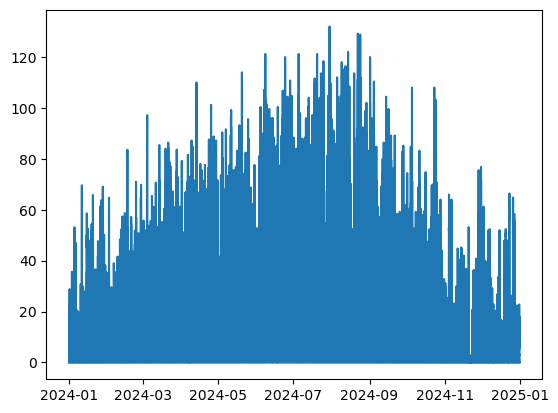

In [4]:
plt.plot(dts1.Date_utc.dt.tz_localize(None), dts1['PV'])

In [5]:
temp = pd.read_csv(root_proj / f"DATA_SYSTEM_LIDL/Temperature/orly_{year}_hourly_weather.csv", sep=",")
temp["Date"]= pd.to_datetime(temp["time"], utc=True)
temp["Date_utc"] = pd.to_datetime(temp["time"], utc=True).dt.tz_localize(None)
temp['offset'] = (temp["Date"].dt.tz_convert("Europe/Paris").dt.tz_localize(None) - temp["Date_utc"]).dt.total_seconds()//3600
temp

,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco,Date,Date_utc,offset
0,2024-01-01 01:00:00+01:00,7.0,3.8,80.0,0.0,0.0,230.0,22.3,46.0,1007.6,NaN,2.0,2024-01-01 00:00:00+00:00,2024-01-01 00:00:00,1.0
1,2024-01-01 02:00:00+01:00,6.9,4.0,82.0,0.0,NaN,240.0,22.3,42.6,1007.8,NaN,2.0,2024-01-01 01:00:00+00:00,2024-01-01 01:00:00,1.0
2,2024-01-01 03:00:00+01:00,6.3,3.6,83.0,0.0,NaN,230.0,16.6,42.6,1008.3,NaN,2.0,2024-01-01 02:00:00+00:00,2024-01-01 02:00:00,1.0
3,2024-01-01 04:00:00+01:00,6.1,3.4,83.0,0.0,0.0,230.0,18.4,31.0,1008.7,NaN,2.0,2024-01-01 03:00:00+00:00,2024-01-01 03:00:00,1.0
4,2024-01-01 05:00:00+01:00,5.9,3.1,82.0,0.0,NaN,240.0,18.4,37.0,1009.2,NaN,2.0,2024-01-01 04:00:00+00:00,2024-01-01 04:00:00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31 20:00:00+01:00,3.7,3.3,97.0,0.0,NaN,190.0,18.4,25.9,1029.1,NaN,4.0,2024-12-31 19:00:00+00:00,2024-12-31 19:00:00,1.0
8780,2024-12-31 21:00:00+01:00,4.1,3.4,95.0,0.0,NaN,200.0,22.3,25.9,1028.9,NaN,4.0,2024-12-31 20:00:00+00:00,2024-12-31 20:00:00,1.0
8781,2024-12-31 22:00:00+01:00,4.6,3.7,94.0,0.0,0.0,210.0,20.5,39.0,1028.8,NaN,4.0,2024-12-31 21:00:00+00:00,2024-12-31 21:00:00,1.0
8782,2024-12-31 23:00:00+01:00,4.5,3.8,95.0,0.0,NaN,220.0,24.1,27.8,1028.7,NaN,5.0,2024-12-31 22:00:00+00:00,2024-12-31 22:00:00,1.0


In [6]:
temp_wanted = temp[temp["Date_utc"] <= "2024-12-31 00:00:00"]
temp_wanted = temp_wanted.set_index("Date_utc")
dts_t = temp_wanted.resample("15min").ffill()
dts_t = dts_t.reset_index()
dts_t = dts_t[["Date_utc","offset",'temp']]
dts_t

,Date_utc,offset,temp
0,2024-01-01 00:00:00,1.0,7.0
1,2024-01-01 00:15:00,1.0,7.0
2,2024-01-01 00:30:00,1.0,7.0
3,2024-01-01 00:45:00,1.0,7.0
4,2024-01-01 01:00:00,1.0,6.9
...,...,...,...
35036,2024-12-30 23:00:00,1.0,1.2
35037,2024-12-30 23:15:00,1.0,1.2
35038,2024-12-30 23:30:00,1.0,1.2
35039,2024-12-30 23:45:00,1.0,1.2


In [7]:
dts = dts1.merge(dts_t[['Date_utc','temp']], on="Date_utc")
dts


,Date,PV,Date_utc,offset,temp
0,1/01/2024 1:00,0.0,2024-01-01 00:00:00,1.0,7.0
1,1/01/2024 1:15,0.0,2024-01-01 00:15:00,1.0,7.0
2,1/01/2024 1:30,0.0,2024-01-01 00:30:00,1.0,7.0
3,1/01/2024 1:45,0.0,2024-01-01 00:45:00,1.0,7.0
4,1/01/2024 2:00,0.0,2024-01-01 01:00:00,1.0,6.9
...,...,...,...,...,...
34941,31/12/2024 0:00,0.0,2024-12-30 23:00:00,1.0,1.2
34942,31/12/2024 0:15,0.0,2024-12-30 23:15:00,1.0,1.2
34943,31/12/2024 0:30,0.0,2024-12-30 23:30:00,1.0,1.2
34944,31/12/2024 0:45,0.0,2024-12-30 23:45:00,1.0,1.2


In [8]:
# dts = dts.drop(columns=['Date'])
dts = dts[['Date_utc','offset','PV','temp']]
dts = dts.rename(columns={"Date_utc":"Date"})
dts


,Date,offset,PV,temp
0,2024-01-01 00:00:00,1.0,0.0,7.0
1,2024-01-01 00:15:00,1.0,0.0,7.0
2,2024-01-01 00:30:00,1.0,0.0,7.0
3,2024-01-01 00:45:00,1.0,0.0,7.0
4,2024-01-01 01:00:00,1.0,0.0,6.9
...,...,...,...,...
34941,2024-12-30 23:00:00,1.0,0.0,1.2
34942,2024-12-30 23:15:00,1.0,0.0,1.2
34943,2024-12-30 23:30:00,1.0,0.0,1.2
34944,2024-12-30 23:45:00,1.0,0.0,1.2


In [9]:
dts['hour'] = dts['Date'].dt.hour
# dts['minute'] = pd.to_datetime(dts['Date'],dayfirst=True).dt.minute
dts['dayofyear'] = pd.to_datetime(dts['Date'],dayfirst=True).dt.dayofyear
dts['month'] = pd.to_datetime(dts['Date'],dayfirst=True).dt.month
dts['dayofweek'] = pd.to_datetime(dts['Date'],dayfirst=True).dt.dayofweek
dts['hour_sin'] = np.sin(2*np.pi*dts['hour']/24)
dts['hour_cos'] = np.cos(2*np.pi*dts['hour']/24)
dts['doy_sin'] = np.sin(2*np.pi*dts['dayofyear']/365)
dts['doy_cos'] = np.cos(2*np.pi*dts['dayofyear']/365)
dts['dow_sin'] = np.sin(2*np.pi*dts['dayofweek']/7)
dts['dow_cos'] = np.cos(2*np.pi*dts['dayofweek']/7)

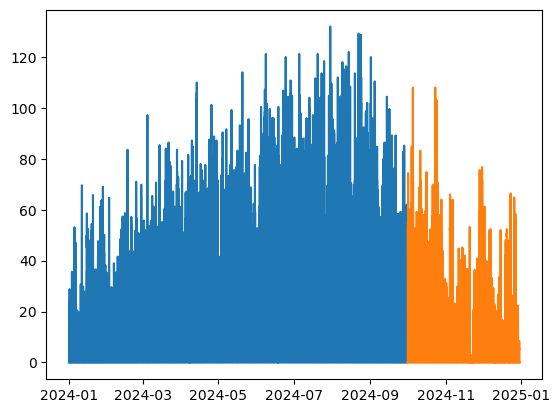

In [10]:
initial = dts.index[dts['Date'] == pd.Timestamp('2024-10-01 01:00:00', tz='Europe/Paris').tz_convert("UTC").tz_localize(None)][0]
# final = dts.index[dts['Date'] == pd.Timestamp('2022-12-05 01:00:00', tz='Europe/Paris').tz_convert("UTC").tz_localize(None)][0]

df_train = dts.iloc[:initial]
df_test = dts.iloc[initial:]
# df_after = dts.iloc[final:]
plt.plot(df_train.Date.dt.tz_localize(None), df_train['PV'], label='Train')
plt.plot(df_test.Date.dt.tz_localize(None), df_test['PV'], label='Test')
# plt.plot(df_after.Date.dt.tz_localize(None), df_after['PV'], label='After')


In [17]:
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
days = 30
forecaster = ForecasterRecursive(
    # estimator = XGBRegressor(n_estimators=460, learning_rate=0.01, random_state=42),
        estimator = LGBMRegressor(random_state=15926, verbose=-1),
    # estimator= RandomForestRegressor(random_state=42),
    # lags = int((60/15)*24*days), # use previous month
    window_features = RollingFeatures(stats=['max','std'], window_sizes=int((60/15)*24))
)

In [18]:
import joblib as jb
import json

output_dir = root_proj / "checkpoints" / "2024"/ "predictions" / "pv_30d_lgbm_2024_temp"

if not (output_dir / "log.json").is_file(): # first train
    output_dir.mkdir(parents=True, exist_ok=True)
    # training
    forecaster.fit(y=df_train['PV'],exog=df_train[['temp']], store_in_sample_residuals=True)
    # residuals = forecaster.in_sample_residuals  # 查看训练残差
    # save model
    jb.dump(forecaster, output_dir/"model.joblib")
    # log
    log = {
        "metadata": {
            "description": "recursive lgbm",
            "lags": int(forecaster.lags[-1]),
            "window_features": {
                "type": forecaster.window_features[0].__class__.__name__ ,
                "stats": forecaster.window_features[0].stats,
                "window_size": forecaster.window_features[0].window_sizes
            },
            "freq": "15min"
        },
        # "residuals": forecaster.in_sample_residuals
    }
    # save log
    with open(output_dir/"log.json", "w") as f:
        json.dump(log, f, indent=2)
    print("End of training")
else:
    # 加载模型 | load model
    forecaster = jb.load(output_dir/"model.joblib")
    # load log
    with open(output_dir/"log.json", "r") as f:
        log = json.load(f)
    print("Loaded")

Loaded


In [19]:
daysa = 96*4
yhat_test = forecaster.predict(steps=daysa, exog=df_test[['temp']].iloc[:daysa])

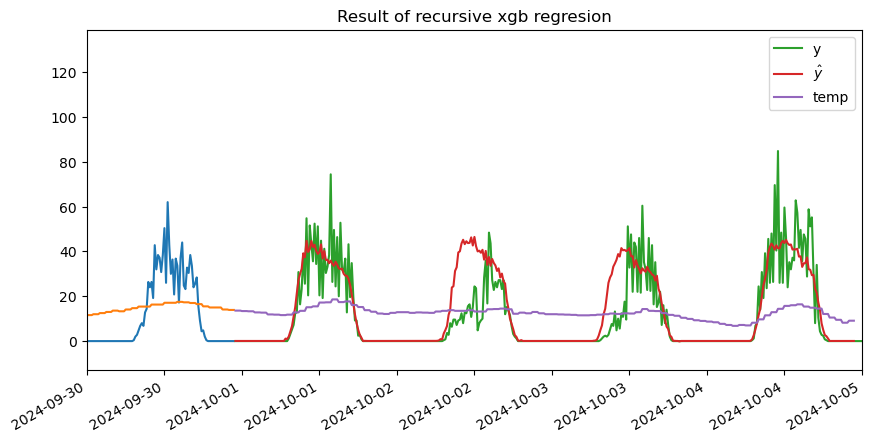

In [20]:
# Save and display the plot
import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Result of recursive xgb regresion")
ax.plot(df_train['Date'],df_train['PV'])
ax.plot(df_train['Date'],df_train['temp'])
ax.plot(df_test['Date'], df_test['PV'], label='y')
ax.plot(df_test['Date'][:daysa], yhat_test, label=r'$\hat{y}$')
ax.plot(df_test['Date'][:daysa],df_test['temp'][:daysa], label='temp')
# ax.plot(df_after.Date.dt.tz_localize(None), df_after['PV'], label='After')

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

ax.set_xlim(pd.Timestamp('2024-09-30'), pd.Timestamp('2024-10-05'))

# optional: minor ticks every 6 hours
# ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

ax.legend()

fig.autofmt_xdate() # for rotation
fig.savefig(output_dir / "prediction_test.png", dpi=300, bbox_inches='tight')
plt.show()

In [45]:
energy_test = []
energy_pred = []
for i in range(daysa):
    energy_test.append(df_test['PV'].iloc[i]*0.25) # 15min = 0.25h
    energy_pred.append(yhat_test.iloc[i]*0.25) # 15min = 0.25h (positional access to avoid KeyError)
energy_test = sum(energy_test)

energy_pred = sum(energy_pred)
error = abs(energy_test-energy_pred)*100/energy_test
print(f"Energy test: {energy_test:.2f} kWh")
print(f"Energy prediction: {energy_pred:.2f} kWh")
print(f"Error: {error:.2f} %")

Energy test: 1090.80 kWh
Energy prediction: 1332.42 kWh
Error: 22.15 %


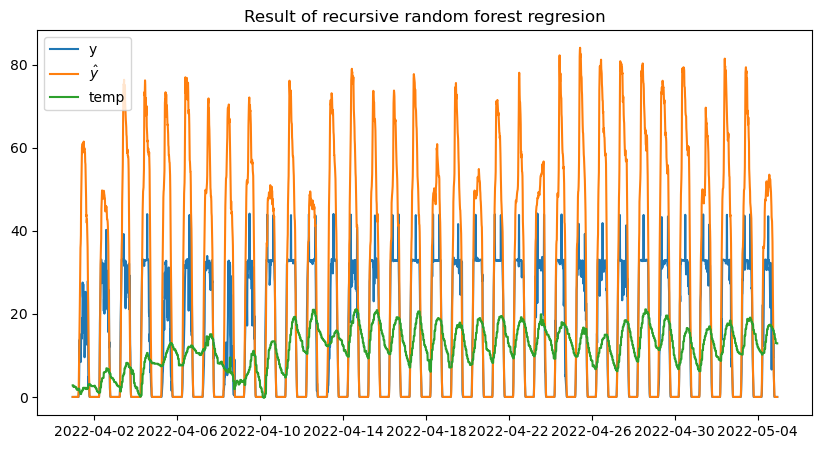

In [167]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Result of recursive random forest regresion")
# ax.plot(df_train['Date'],df_train['PV'])
# ax.plot(df_train['Date'],df_train['temp'])
ax.plot(df_test['Date'], df_test['PV'], label='y')
ax.plot(df_test['Date'], yhat_test, label=r'$\hat{y}$')
ax.plot(df_test['Date'],df_test['temp'], label='temp')
# ax.plot(df_after['Date'],df_after['PV'])

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

# optional: minor ticks every 6 hours
# ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

ax.legend()

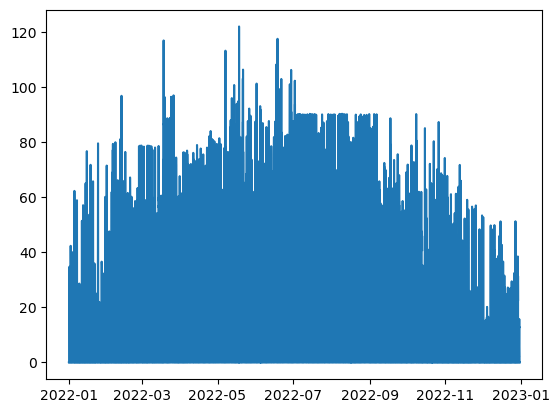

In [168]:
dts_fix = dts.copy()
dts_fix.loc[initial:final-1, 'PV'] = yhat_test.values
plt.plot(dts_fix.Date.dt.tz_localize(None), dts_fix['PV'], label='Train')

In [152]:
yhat_test

8636     0.208457
8637     0.208457
8638     0.208457
8639     0.208457
8640     0.208457
           ...   
11895    0.476592
11896    0.476592
11897    0.476592
11898    0.476592
11899    0.476592
Name: pred, Length: 3264, dtype: float64